In [1]:

# Import packages
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import dates as mdates
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from pmdarima import auto_arima
import pmdarima as pm
from scipy.stats import boxcox
from scipy.special import inv_boxcox

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from busy_airports.baselines import NaiveSeasonalWithDrift, TripleExponentialSmoothing
from busy_airports.preprocessing import load_data, retrieve_airport_data
from busy_airports.metrics import evaluate_forecast
from busy_airports.data_splits import make_rolling_splits, make_rolling_splits_weekly
from busy_airports.models import STLArima



In [2]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

We first import the airport data for Chicago airport and separate into daily and weekly sections.

In [3]:
#Import and process daily and weekly data for Chicago airport
data = load_data("../data/tsa-throughput-data-complete.csv")
data_ord_d = retrieve_airport_data(data, "ORD", frequency="D") #Daily data
data_ord_w = retrieve_airport_data(data, "ORD", frequency="W") #Weekly data


Let's see a plot of the data.

In [7]:
#Let's visualize the daily and weekly throughput data for Chicago O'Hare
px.line(data_ord_d, x='datetime', y='total_passenger_throughput', 
        labels={'total_passenger_throughput': 'Daily Throughput','datetime': 'Date'},
        template="simple_white", 
        title='Daily Throughput at ORD',
        height=500, width=1000).update_layout(font=dict(size=14), title_x=0.5).show()

px.line(data_ord_w, x='datetime', y='total_passenger_throughput', 
        labels={'total_passenger_throughput': 'Weekly Throughput','datetime': 'Date'},
        template="simple_white", 
        title='Weekly Throughput at ORD',
        height=500, width=1000).update_layout(font=dict(size=14), title_x=0.5).show()

 We keep the data after June 2025 untouched for testing. We will define the training data first. We will eventually train the STL+ARIMA model on cross validated splits. We first use the entire training data to find the best parameters for Arima.

Daily Data Analysis

In [9]:
data_ord_d_train= data_ord_d[data_ord_d["datetime"] < "2025-06-24"]  #Daily training data

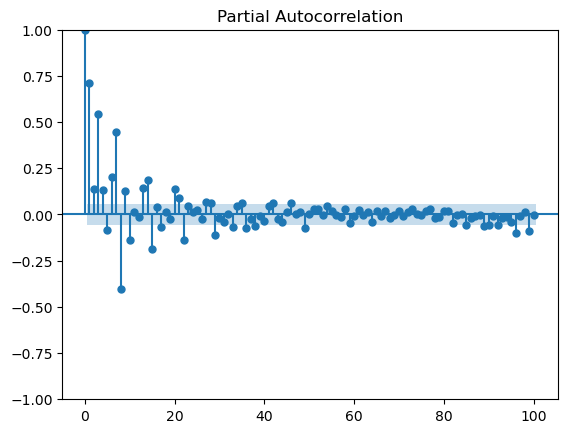

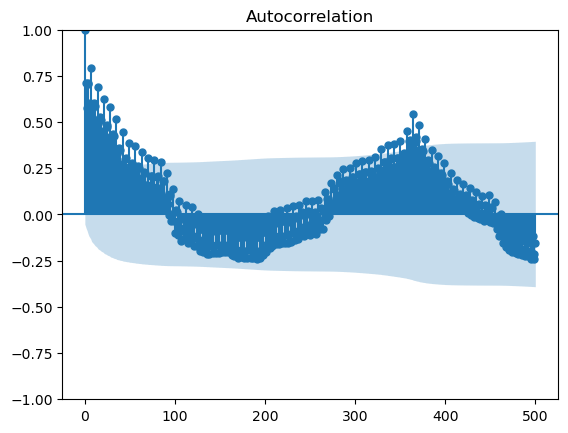

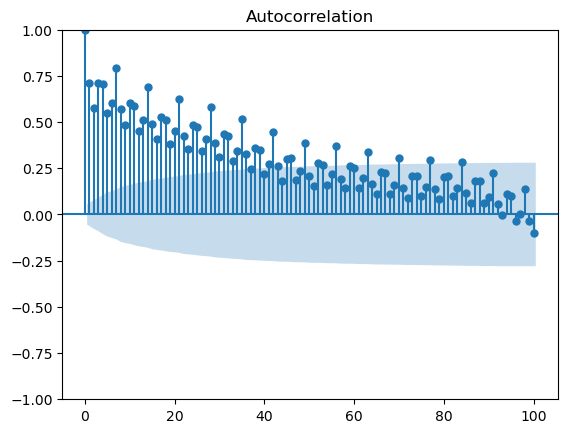

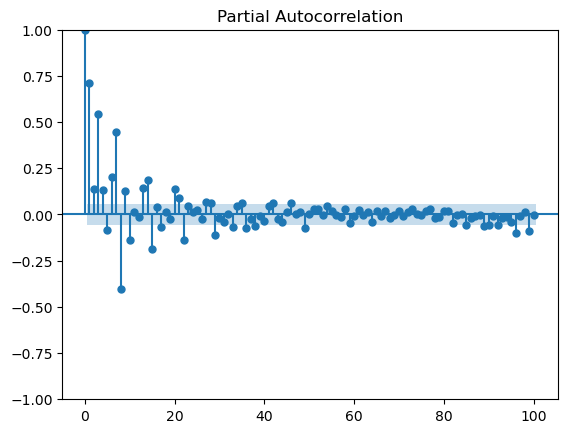

In [10]:
#ACF, PACF plots
plot_acf(data_ord_d_train['total_passenger_throughput'], lags=500)
plot_acf(data_ord_d_train['total_passenger_throughput'], lags=100)
plot_pacf(data_ord_d_train['total_passenger_throughput'], lags=100)

 Note that above plots show significant seasonality on timescales of a year as well as a significant seasonality on timescales of a week. The ACF pattern in the second plot suggests a SARIMA model might give a good approximation. The periodicity over monthly scales is much less significant. 


Let's run an STL decomposition on the training data.

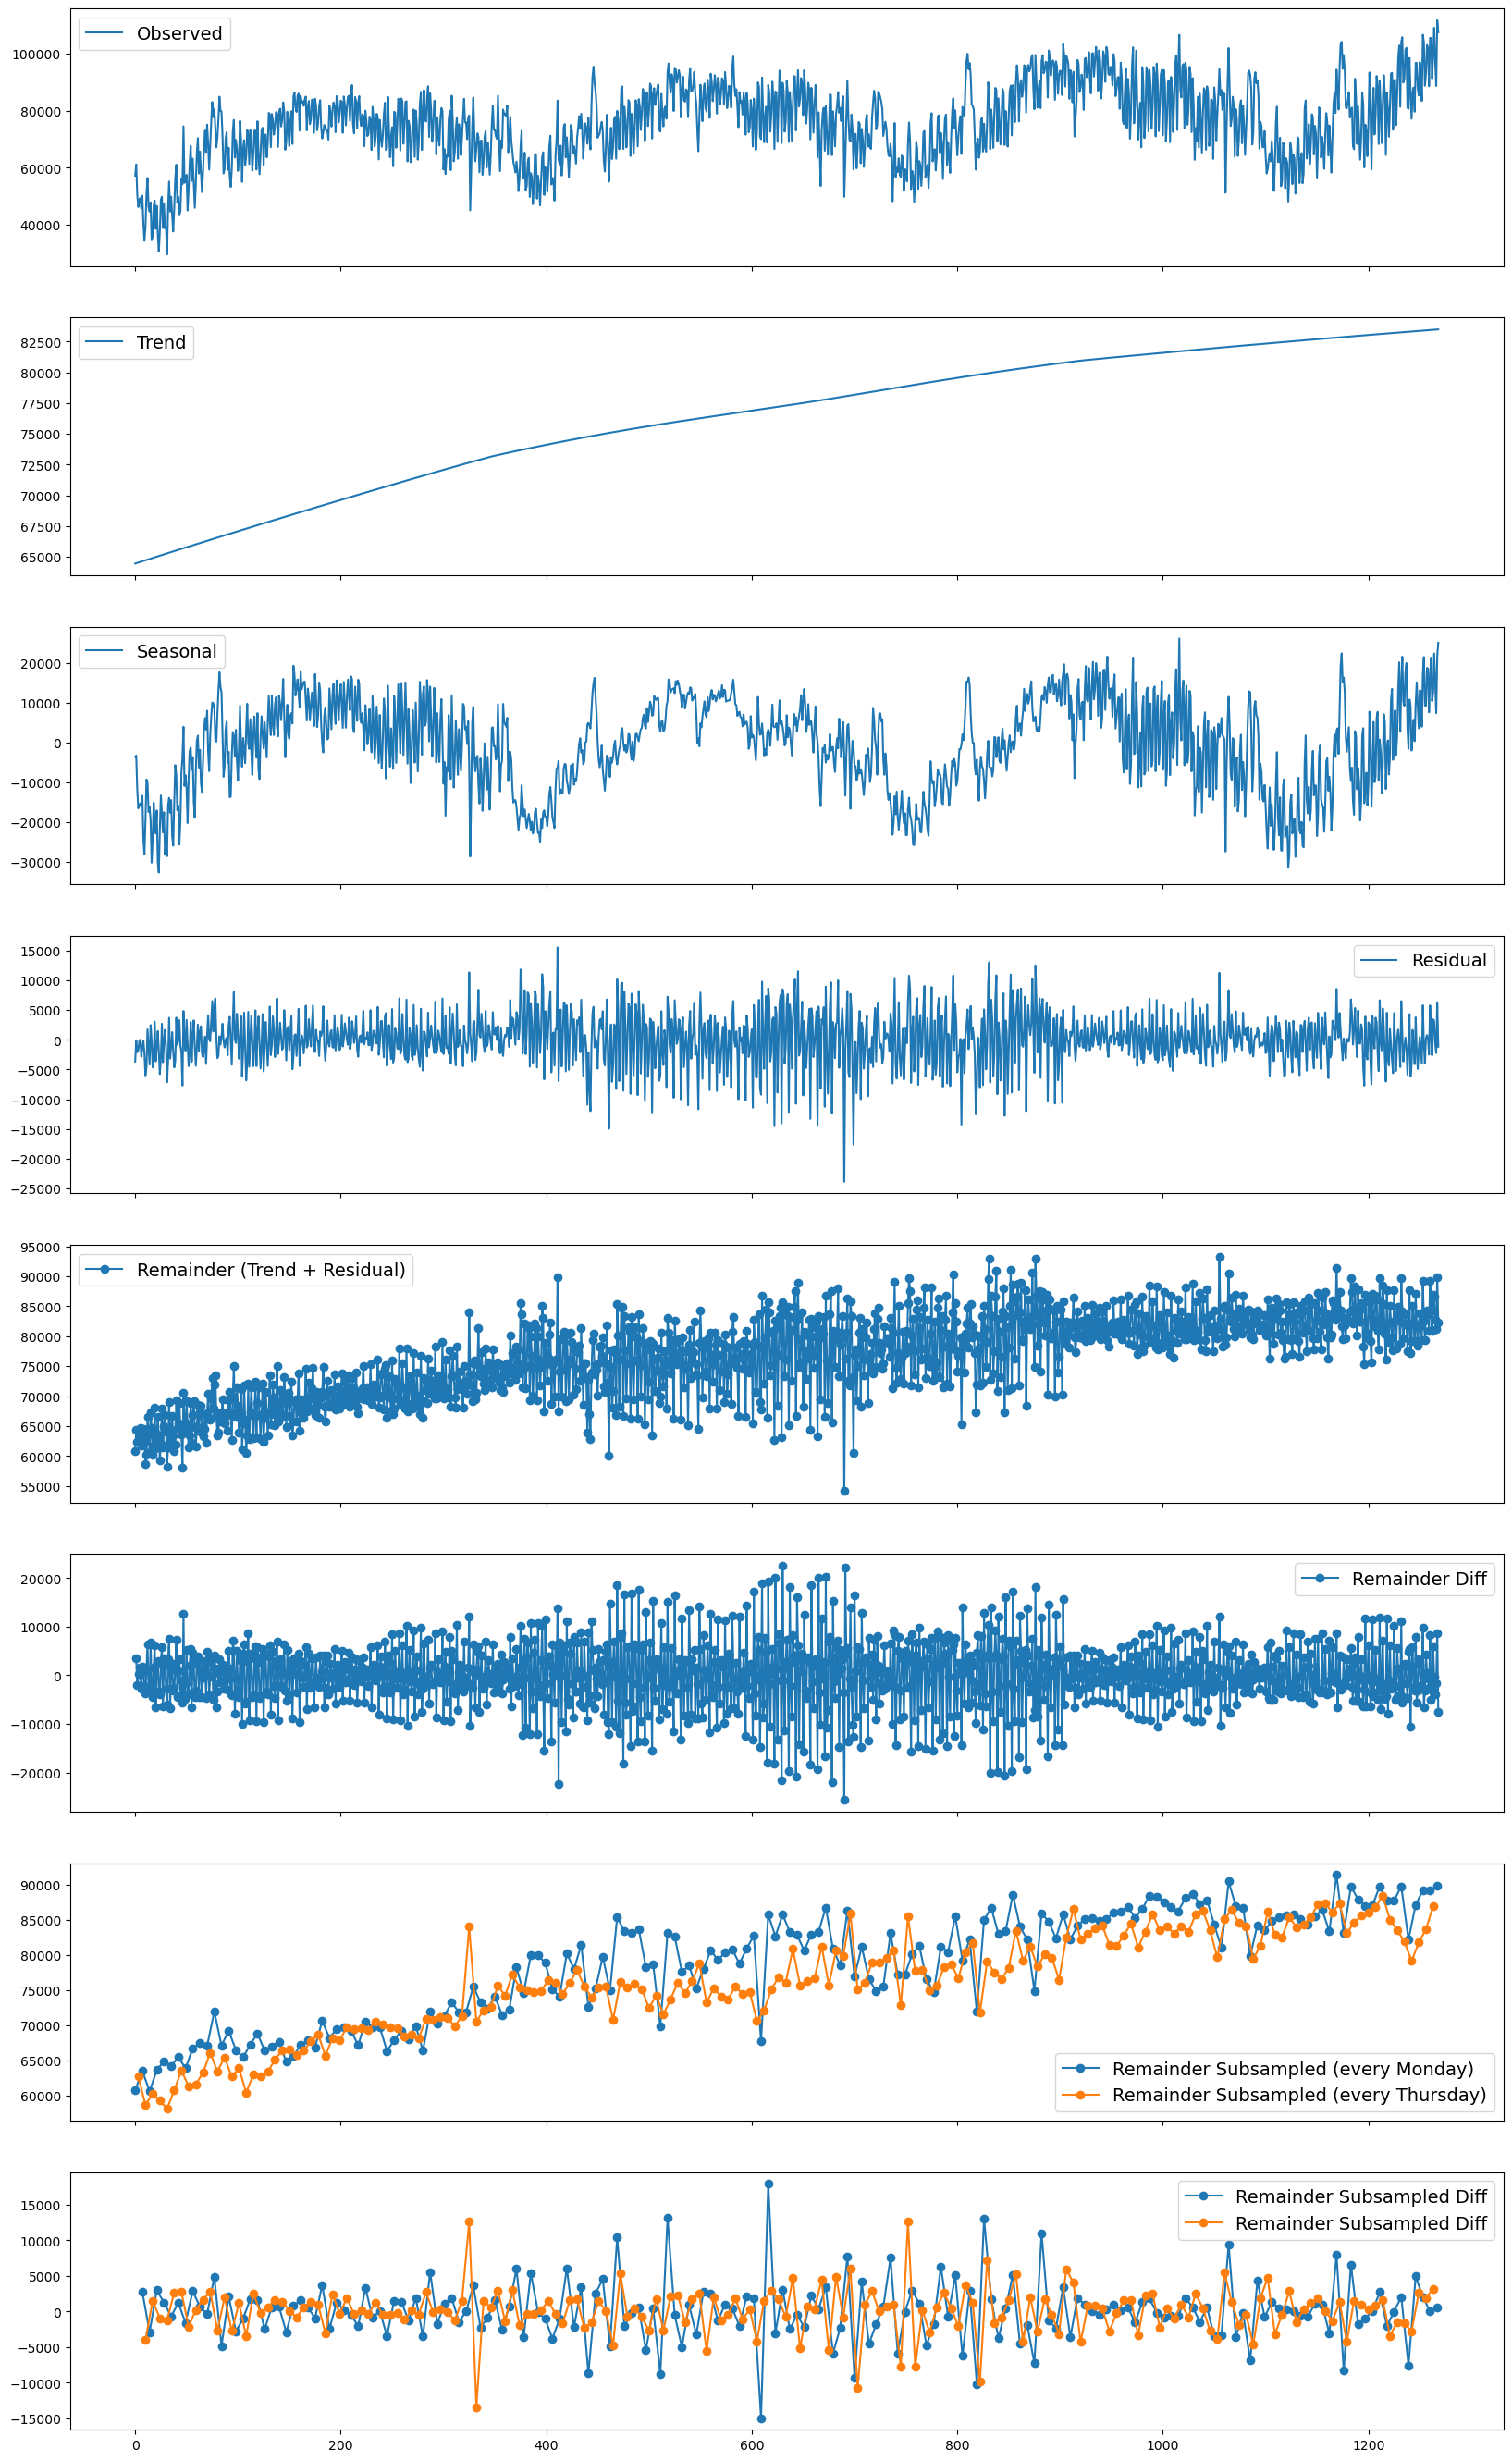

In [11]:
# Initialise the STL decomposition class with the daily data. Set robust=True to make the decomposition more resistant to outliers like leap days or bank holidays or government shutdowns :-P

stl_daily = STL(data_ord_d_train['total_passenger_throughput'], period=365)
stl_daily_results = stl_daily.fit()

stl_daily_trend = stl_daily_results.trend
stl_daily_seasonal = stl_daily_results.seasonal
stl_daily_resid = stl_daily_results.resid
stl_daily_base = stl_daily_results.observed 

stl_daily_trend_diff = stl_daily_trend.diff()
stl_daily_remainder = stl_daily_trend + stl_daily_resid
stl_daily_remainder_diff = stl_daily_remainder.diff()

stl_remainder_sub1 = stl_daily_remainder.iloc[::7]
stl_remainder_sub1_diff = stl_remainder_sub1.diff()

stl_remainder_sub2 = stl_daily_remainder.iloc[3::7]
stl_remainder_sub2_diff = stl_remainder_sub2.diff()



fig, ax = plt.subplots(8, 1, figsize=(20, 34), sharex=True)

ax[0].plot(stl_daily_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_daily_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_daily_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_daily_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_daily_remainder, label='Remainder (Trend + Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_daily_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)
ax[6].plot(stl_remainder_sub1, label='Remainder Subsampled (every Monday)', marker='o')
ax[6].plot(stl_remainder_sub2, label='Remainder Subsampled (every Thursday)', marker='o')
ax[6].legend(fontsize=14)
ax[7].plot(stl_remainder_sub1_diff, label='Remainder Subsampled Diff', marker='o')
ax[7].plot(stl_remainder_sub2_diff, label='Remainder Subsampled Diff', marker='o')
ax[7].legend(fontsize=14)


plt.show()


From above decomposition, the remainder series (i.e Trend + Seasonal) looks strongly like difference stationary suggesting d = 1 in SARIMA fitting. 
To learn about order of SARIMA, let's see what the PACFs look like of the remainder series of both weekly subsamples and otherwise.

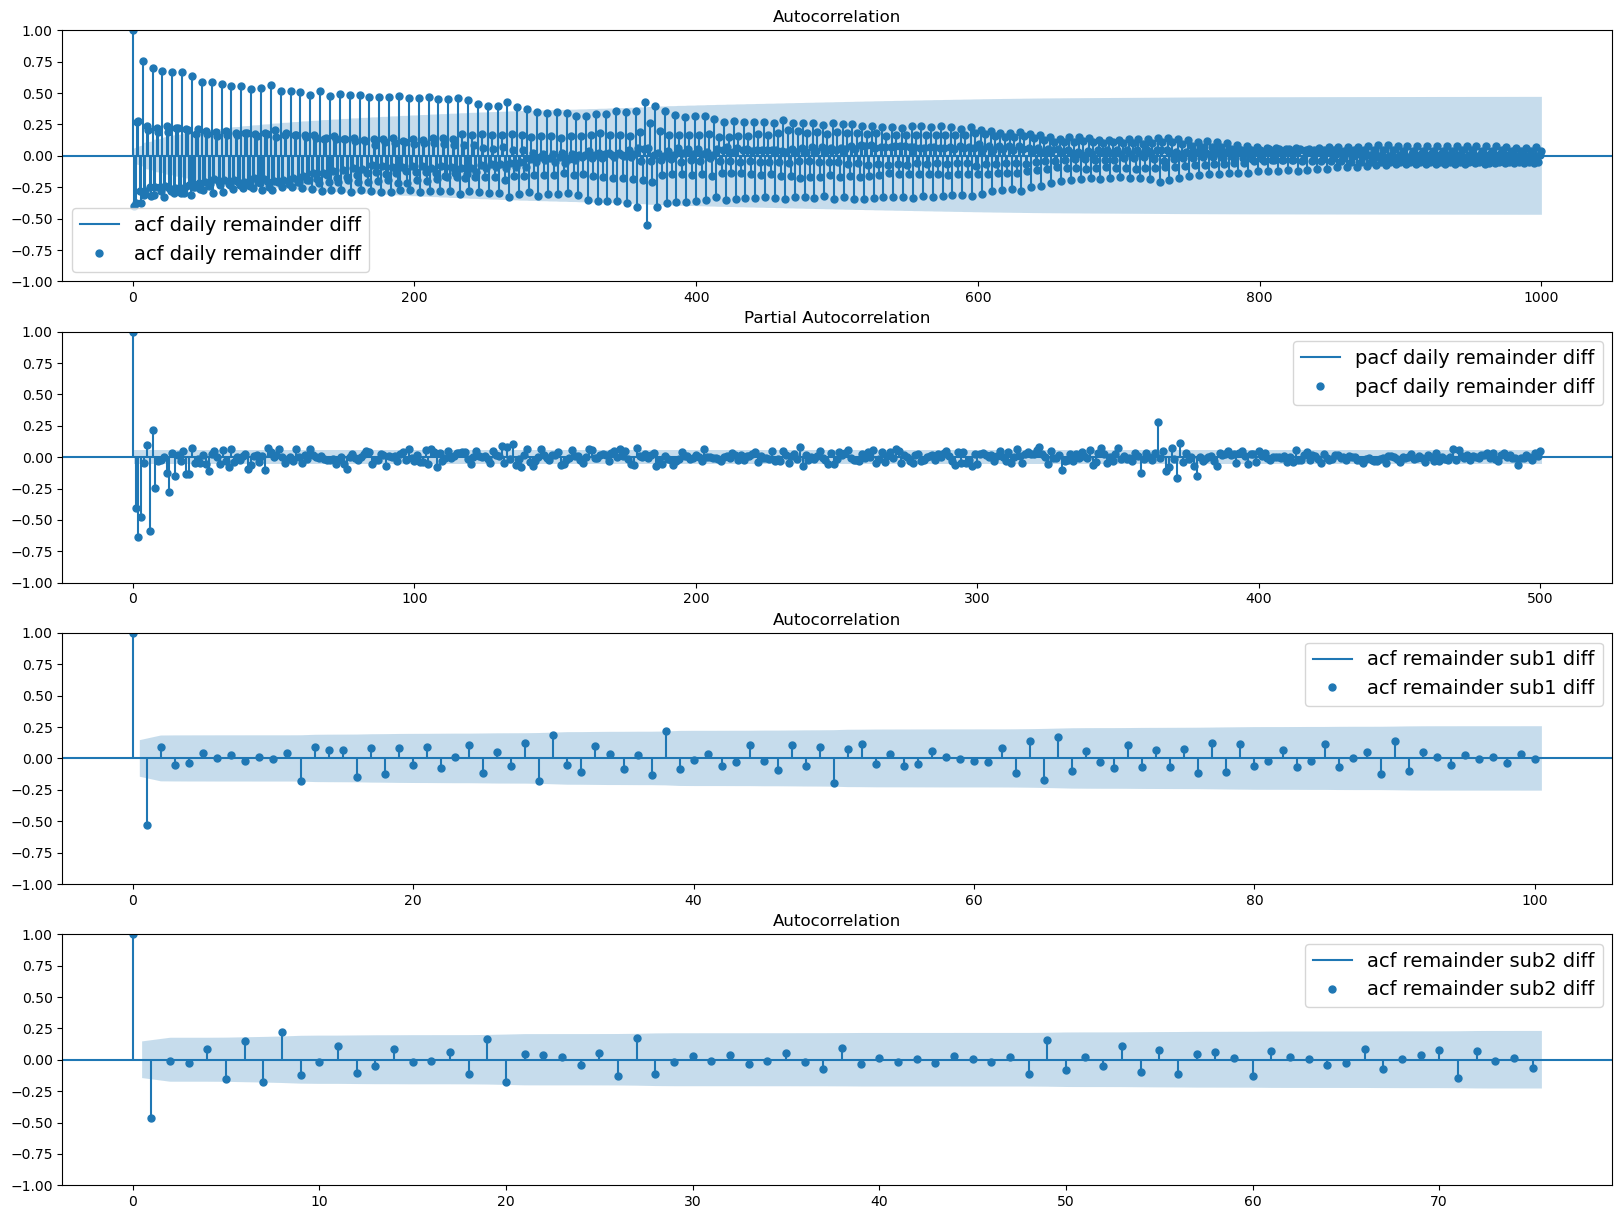

In [12]:
fig, ax = plt.subplots(4, 1, figsize=(20, 15))
plot_acf(stl_daily_remainder_diff.dropna(), lags=1000, ax=ax[0], label='acf daily remainder diff')
ax[0].legend(fontsize=14)
plot_pacf(stl_daily_remainder_diff.dropna(), lags=500, ax=ax[1], label='pacf daily remainder diff')
ax[1].legend(fontsize=14)
plot_acf(stl_remainder_sub1_diff.dropna(), lags=100, ax=ax[2], label='acf remainder sub1 diff')
ax[2].legend(fontsize=14)
plot_acf(stl_remainder_sub2_diff.dropna(), lags=75, ax=ax[3], label='acf remainder sub2 diff')
ax[3].legend(fontsize=14)


NOTE : From the ACF and PACF plots, we see that there is a clear weekly seasonality (as expected) but also a residual yearly seasonality component (small, but significant spikes in PACF at the 365 day mark). For our purposes we ignore this, because we have too few yearly-subsamples to make meaningful predictions. We also don't see a similar yearly regressive component in the pacf and acfs of the weekly subsampled remainder series. 

One guess for SARIMA orders would be ARIMA((p, 1, q), (P, 0, Q, s=7)) for the stl_daily_remainder series with p,q being a bit high (like 2 and above). There is no additional trend across weekly deparated points that is not captured by the global trend. hence d=1 and D=0. Let's check using auto_arima. 

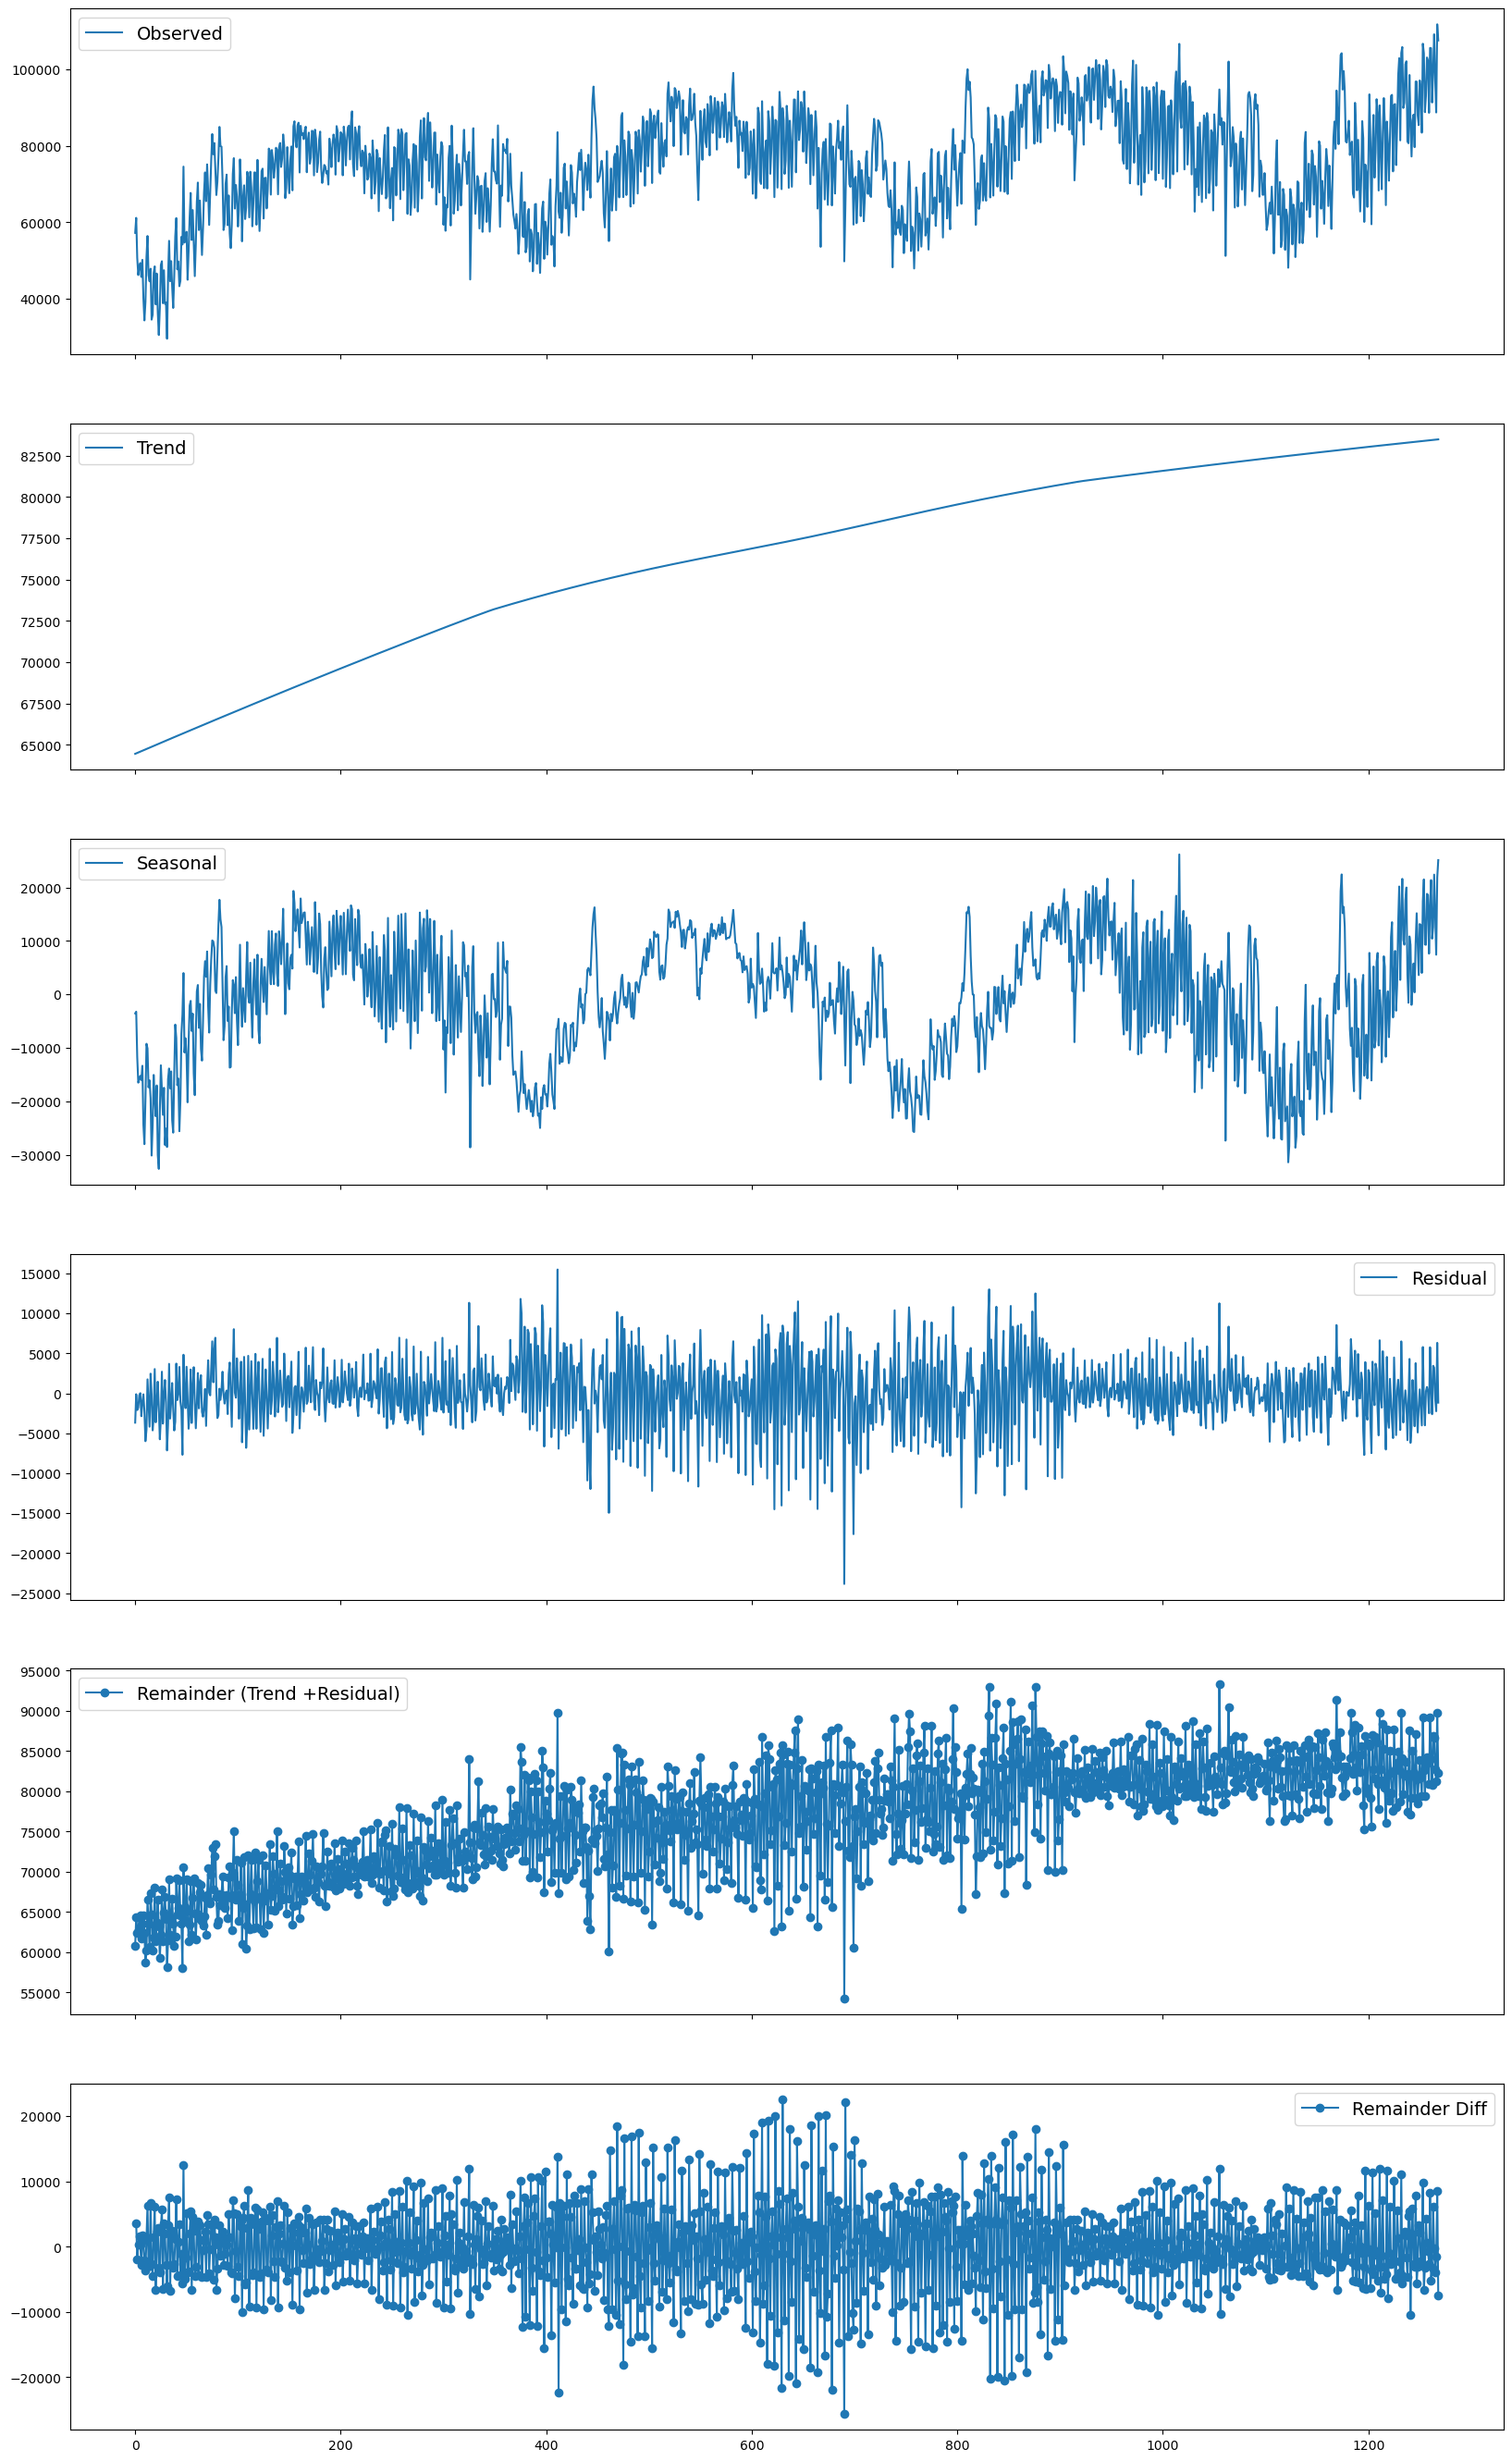

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=24236.869, Time=4.98 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=25891.482, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=24824.667, Time=1.59 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=24671.008, Time=2.43 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=25889.491, Time=0.04 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=24580.467, Time=5.38 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=24458.044, Time=2.02 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=24234.571, Time=10.99 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=24300.849, Time=8.90 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=12.20 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=24235.324, Time=9.83 sec
 ARIMA(1,1,2)(2,0,1)[7] intercept   : AIC=24551.155, Time=7.84 sec
 ARIMA(2,1,1)(2,0,1)[7] intercept   : AIC=24219.731, Time=8.42 sec
 ARIMA(2,1,1)(1,0,1)[7] intercept   : AIC=24223.464, Time=4.93 sec
 ARIMA(2,1,1)(2,0,0)[7]

,order,"(5, ...)"
,seasonal_order,"(2, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,False


In [13]:
# Obtain the auto arima model fitted to the training set (effectively does cross validation to select optimal hyperparameters)
stl_daily = STL(data_ord_d_train['total_passenger_throughput'], period=365)
stl_daily_results = stl_daily.fit()

stl_daily_trend = stl_daily_results.trend
stl_daily_seasonal = stl_daily_results.seasonal
stl_daily_resid = stl_daily_results.resid
stl_daily_base = stl_daily_results.observed

stl_daily_trend_diff = stl_daily_trend.diff()
stl_daily_remainder = stl_daily_trend + stl_daily_resid
stl_daily_remainder_diff = stl_daily_remainder.diff()

fig, ax = plt.subplots(6, 1, figsize=(20, 34), sharex=True)
ax[0].plot(stl_daily_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_daily_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_daily_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_daily_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_daily_remainder, label='Remainder (Trend +Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_daily_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)
plt.show()


auto_arima(stl_daily_remainder, seasonal=True,trace = True, m=7, stepwise=True, suppress_warnings=True, error_action='ignore')


Let's now use cross-validated splits now for better modelling. We use a baseline of the data from 2022 and 2023, and an additional 90 days for each split, for a total of five splits.

In [15]:
#creating splits
splits_d = make_rolling_splits(data_ord_d_train, date_col='datetime', n_splits=5, step_days=90)

Split 1: train → 2024-03-30 | test 2024-03-31 → 2024-06-28 (90 days)
Split 2: train → 2024-06-28 | test 2024-06-29 → 2024-09-26 (90 days)
Split 3: train → 2024-09-26 | test 2024-09-27 → 2024-12-25 (90 days)
Split 4: train → 2024-12-25 | test 2024-12-26 → 2025-03-25 (90 days)
Split 5: train → 2025-03-25 | test 2025-03-26 → 2025-06-23 (90 days)


We will now run our STL+ARIMA model on the CV splits.

In [16]:
#Arima orders for the remainder component of the STL decomposition
p = 5
d = 1
q = 2
P = 2
D = 0
Q = 1
s = 7
results_stl_d=[]
#Running STL + ARIMA on daily data using the splits created above.
for i, (train_idx, test_idx) in enumerate(splits_d):
        if len(test_idx) == 0:
            print(f"Split {i+1}: empty test set, skipping")
            continue

        train = data_ord_d_train.loc[train_idx].copy()
        test  = data_ord_d_train.loc[test_idx].copy()
        n_forecast = len(test_idx)
        model = STLArima(season_length=365,arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
        model.fit(train['total_passenger_throughput'])
        forecasts, lower_bound, upper_bound = model.forecast(n_forecast)
        actuals  = test['total_passenger_throughput'].values
        metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
        metrics['split'] = i + 1
        results_stl_d.append(metrics)
        print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_stl_d_df = pd.DataFrame(results_stl_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_stl_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_stl_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_stl_d_df['rmse'].mean():,.0f}")  



Split 1 - MAE: 8691, MAPE: 10.46%, RMSE: 10341
Split 2 - MAE: 9185, MAPE: 10.66%, RMSE: 11412
Split 3 - MAE: 10365, MAPE: 13.34%, RMSE: 13362
Split 4 - MAE: 7948, MAPE: 11.84%, RMSE: 9891
Split 5 - MAE: 9762, MAPE: 11.96%, RMSE: 12145

CV Average:
  MAE:  9,190
  MAPE: 11.65%
  RMSE: 11,430


For a quick comparison, we can check these results with the exponential smoothing results (see Baseline Forecasts.ipynb for more on baselines).

In [20]:
#For Exp. smoothing
results_tes = []

for i, (train_idx, test_idx) in enumerate(splits_d):
    train = data_ord_d_train.iloc[train_idx]['total_passenger_throughput']
    test  = data_ord_d_train.iloc[test_idx]['total_passenger_throughput']

    model = TripleExponentialSmoothing(season_length=365)
    model.fit(train)
    predicted = model.forecast(h=len(test))

    metrics = evaluate_forecast(test.values, predicted.values, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_tes.append(metrics)
    print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")


results_tes_df = pd.DataFrame(results_tes).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_tes_df['mae'].mean():,.0f}")
print(f"  MAPE: {100*results_tes_df['mape'].mean():.2f}%")
print(f"  RMSE: {results_tes_df['rmse'].mean():,.0f}")

Split 1 - MAE: 8690, MAPE: 10.38%, RMSE: 10283
Split 2 - MAE: 9452, MAPE: 11.43%, RMSE: 11930
Split 3 - MAE: 10609, MAPE: 13.82%, RMSE: 12786
Split 4 - MAE: 8558, MAPE: 12.83%, RMSE: 10457
Split 5 - MAE: 9530, MAPE: 11.50%, RMSE: 11713

CV Average:
  MAE:  9,368
  MAPE: 11.99%
  RMSE: 11,434


We have thus obtained a small improvement over the better of the two baseline models.

Here's a plot of the predicted values across splits along with a 95% confidence interval

In [10]:
data_ord_d_train = data_ord_d_train.set_index('datetime')
data_ord_d_train.index = pd.to_datetime(data_ord_d_train.index)

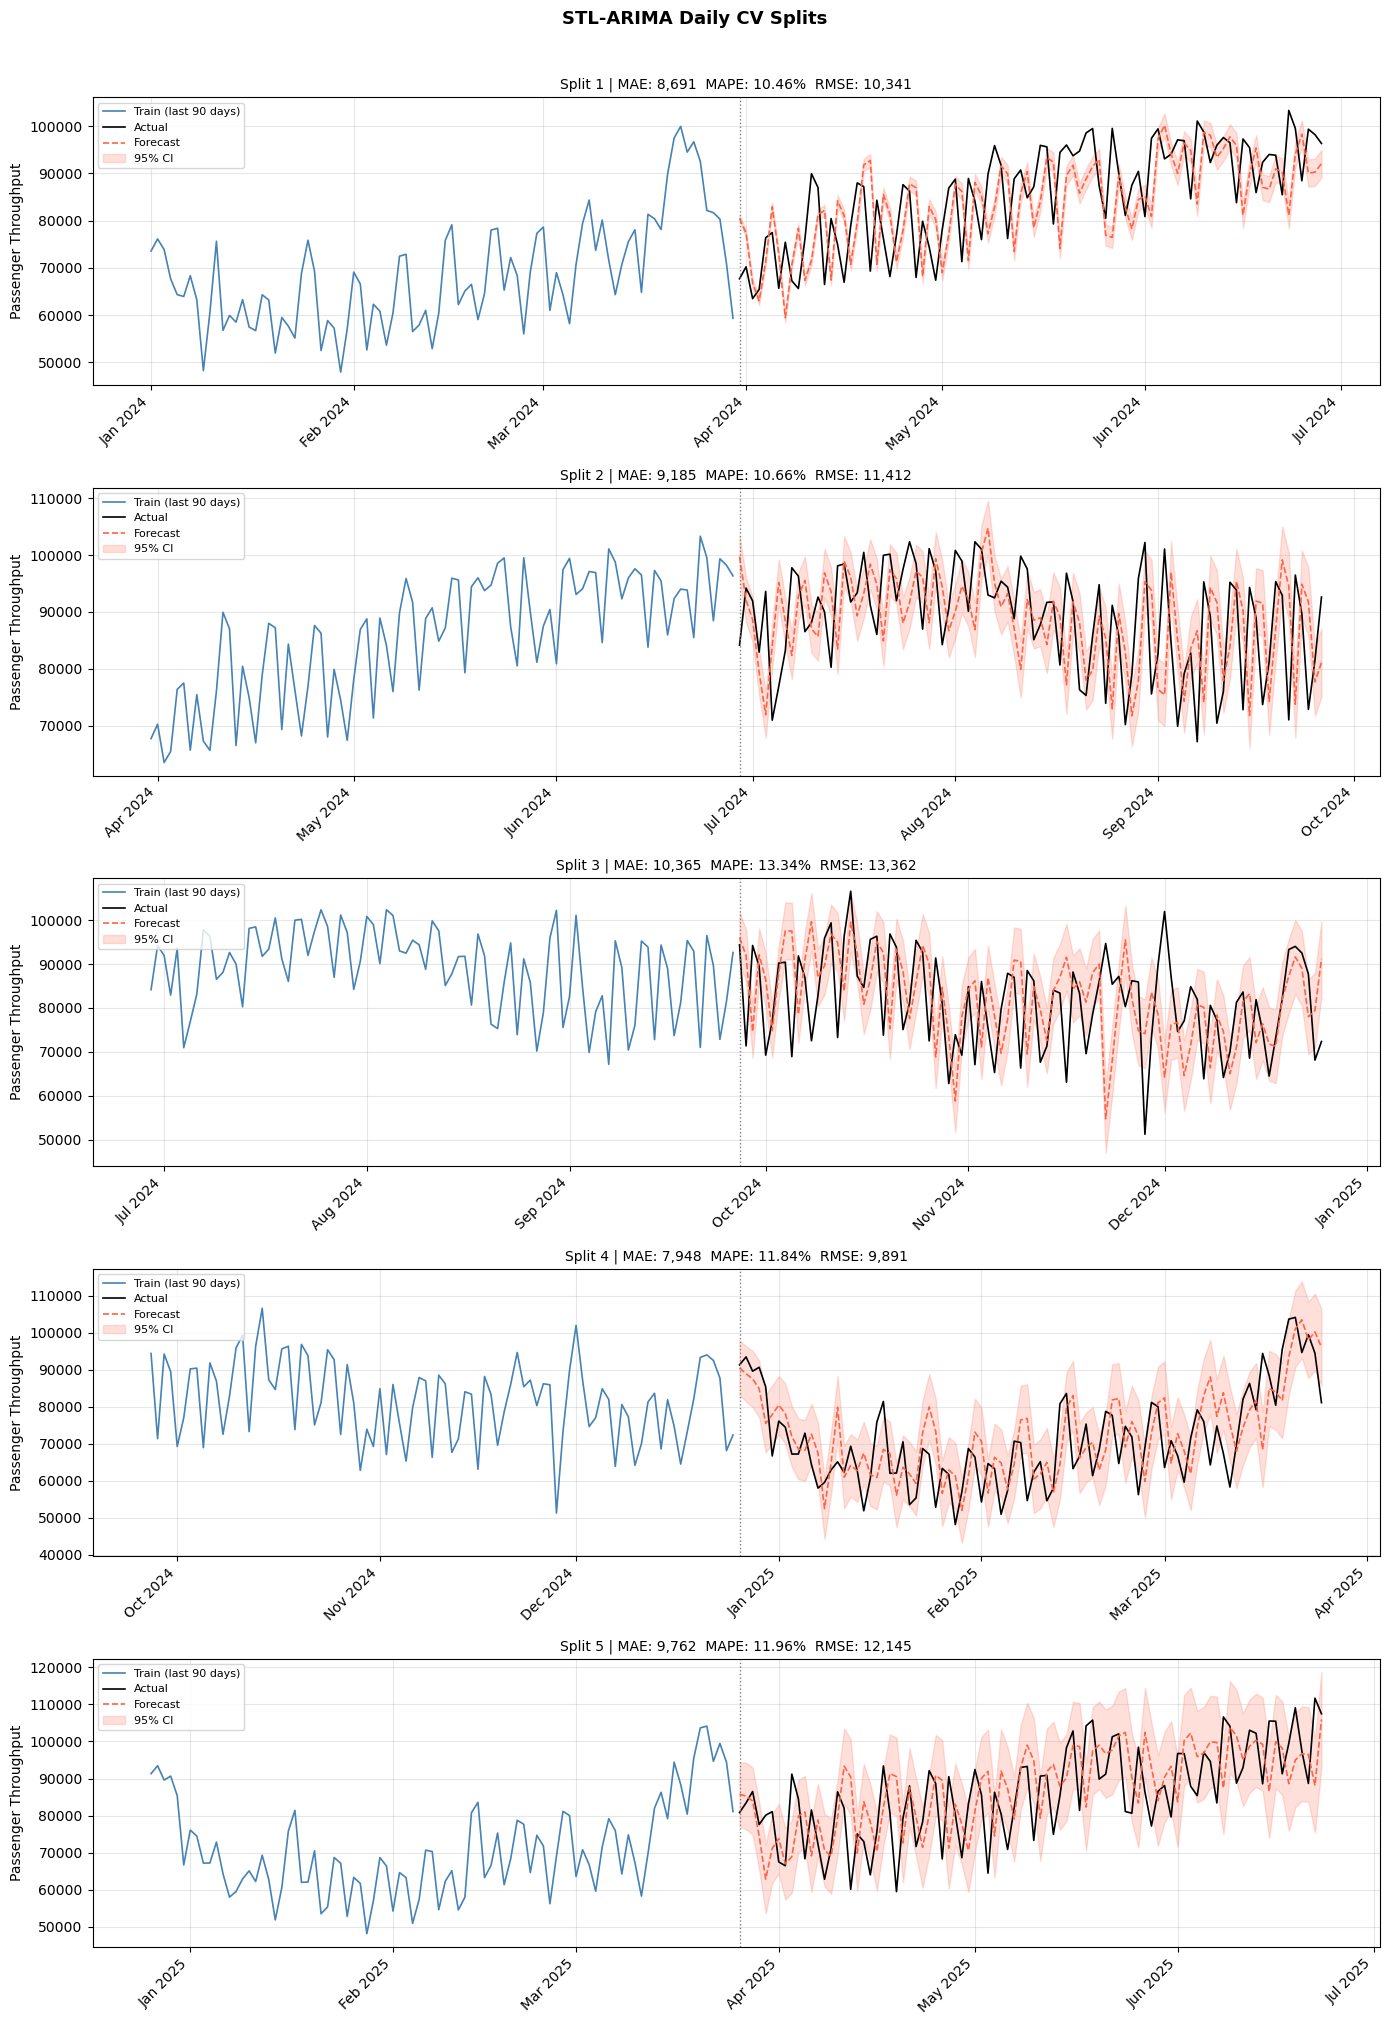

In [11]:

                                        
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_d), 1, figsize=(14, 4 * len(splits_d)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_d):
    ax = axes[i]

    if len(test_idx) == 0:
        print(f"Split {i+1}: empty test set, skipping")
        ax.set_visible(False)
        continue

    train = data_ord_d_train.iloc[train_idx].copy()
    test  = data_ord_d_train.iloc[test_idx].copy()
    n_forecast = len(test_idx)

    model = STLArima(season_length=365, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
    model.fit(train['total_passenger_throughput'])
    forecasts, lower_bound, upper_bound = model.forecast(n_forecast)

    actuals = test['total_passenger_throughput'].values
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_stl_d.append(metrics)

    # --- Plotting ---
    train_dates = train.index
    test_dates  = test.index

    # Plot last N days of training data for context
    context_window = min(90, len(train))
    ax.plot(train_dates[-context_window:],
            train['total_passenger_throughput'].values[-context_window:],
            color='steelblue', label='Train (last 90 days)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('STL-ARIMA Daily CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stl_arima_cv_splits.png', dpi=150, bbox_inches='tight')
plt.show()


Weekly Data Analysis

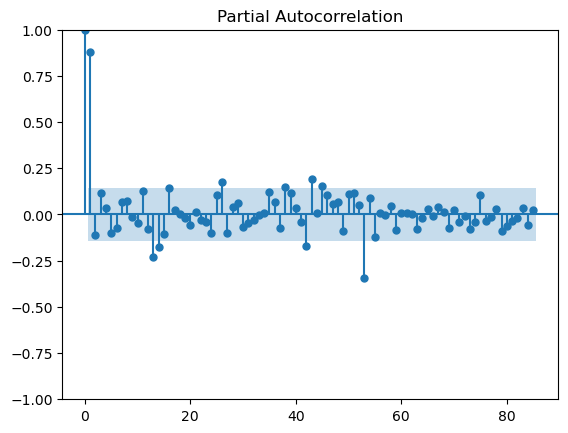

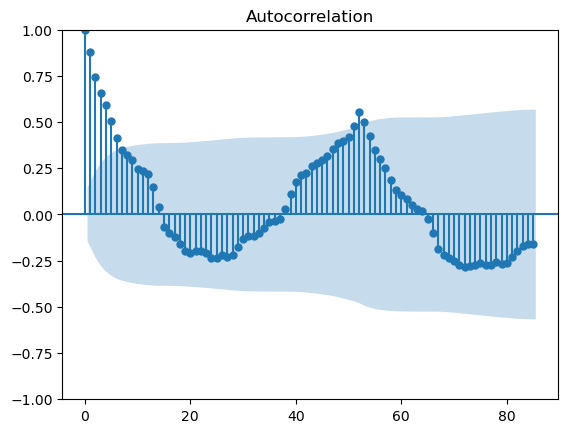

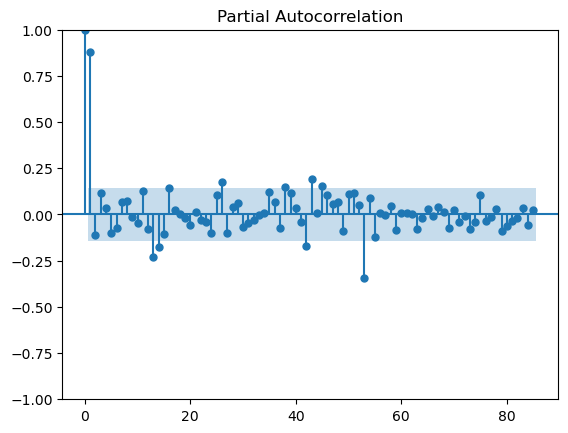

In [23]:

data_ord_w_train= data_ord_w[data_ord_w.index <= 181] #Weekly training data
#ACF, PACF plots

plot_acf(data_ord_w_train['total_passenger_throughput'], lags=85)
plot_pacf(data_ord_w_train['total_passenger_throughput'], lags=85)

We repeat the same steps as in the daily data, first finding the best ARIMA parameters and then training our STL+ARIMA model on cross-validated splits.

In [ ]:
stl_weekly = STL(data_ord_w_train['total_passenger_throughput'], period=52)
stl_weekly_results = stl_weekly.fit()

stl_weekly_trend = stl_weekly_results.trend
stl_weekly_seasonal = stl_weekly_results.seasonal
stl_weekly_resid = stl_weekly_results.resid
stl_weekly_base = stl_weekly_results.observed

stl_weekly_trend_diff = stl_weekly_trend.diff()
stl_weekly_remainder = stl_weekly_trend + stl_weekly_resid
stl_weekly_remainder_diff = stl_weekly_remainder.diff()



fig, ax = plt.subplots(6, 1, figsize=(20, 34), sharex=True)

ax[0].plot(stl_weekly_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_weekly_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_weekly_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_weekly_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_weekly_remainder, label='Remainder (Trend + Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_weekly_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)

plt.show()

auto_arima(stl_weekly_remainder, seasonal=True,trace = True, stepwise=True, suppress_warnings=True, error_action='ignore')


Split 1: train → row 116 (2024-03-31) | test rows 117–129 (2024-04-07 → 2024-06-30) (13 weeks)
Split 2: train → row 129 (2024-06-30) | test rows 130–142 (2024-07-07 → 2024-09-29) (13 weeks)
Split 3: train → row 142 (2024-09-29) | test rows 143–155 (2024-10-06 → 2024-12-29) (13 weeks)
Split 4: train → row 155 (2024-12-29) | test rows 156–168 (2025-01-05 → 2025-03-30) (13 weeks)
Split 5: train → row 168 (2025-03-30) | test rows 169–181 (2025-04-06 → 2025-06-29) (13 weeks)


In [24]:
#Creating Weekly Splits
splits_w = make_rolling_splits_weekly(data_ord_w_train, date_col='datetime', n_splits=5, step_weeks=13)

Split 1: train → row 116 (2024-03-31) | test rows 117–129 (2024-04-07 → 2024-06-30) (13 weeks)
Split 2: train → row 129 (2024-06-30) | test rows 130–142 (2024-07-07 → 2024-09-29) (13 weeks)
Split 3: train → row 142 (2024-09-29) | test rows 143–155 (2024-10-06 → 2024-12-29) (13 weeks)
Split 4: train → row 155 (2024-12-29) | test rows 156–168 (2025-01-05 → 2025-03-30) (13 weeks)
Split 5: train → row 168 (2025-03-30) | test rows 169–181 (2025-04-06 → 2025-06-29) (13 weeks)


In [25]:
#Running STL + ARIMA on weekly data using the splits created above.

results_stl_w = []
for i, (train_idx, test_idx) in enumerate(splits_w):
        if len(test_idx) == 0:
            print(f"Split {i+1}: empty test set, skipping")
            continue

        train = data_ord_w_train.loc[train_idx].copy()
        test  = data_ord_w_train.loc[test_idx].copy()
        n_forecast = len(test_idx)
        model = STLArima(season_length=52,arima_order=(0,1,0), seasonal_order=(0,0,0,0))
        model.fit(train['total_passenger_throughput'])
        forecasts, lower_bound, upper_bound = model.forecast(n_forecast)
        actuals  = test['total_passenger_throughput'].values
        metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
        metrics['split'] = i + 1
        results_stl_w.append(metrics)
        print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_stl_w_df = pd.DataFrame(results_stl_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_stl_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_stl_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_stl_w_df['rmse'].mean():,.0f}")  



Split 1 - MAE: 15545, MAPE: 2.56%, RMSE: 19029
Split 2 - MAE: 13794, MAPE: 2.19%, RMSE: 15848
Split 3 - MAE: 22343, MAPE: 3.89%, RMSE: 26690
Split 4 - MAE: 22879, MAPE: 4.91%, RMSE: 27775
Split 5 - MAE: 30219, MAPE: 5.17%, RMSE: 36578

CV Average:
  MAE:  20,956
  MAPE: 3.74%
  RMSE: 25,184


In [27]:
#Once again we can compare with Exp. smoothing on weekly data.
results_tes_w = []

for i, (train_idx, test_idx) in enumerate(splits_w):
    train = data_ord_w_train.iloc[train_idx]['total_passenger_throughput']
    test  = data_ord_w_train.iloc[test_idx]['total_passenger_throughput']

    model = TripleExponentialSmoothing(season_length=52)
    model.fit(train)
    predicted = model.forecast(h=len(test))

    metrics = evaluate_forecast(test.values, predicted.values, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_tes_w.append(metrics)
    print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_tes_w_df = pd.DataFrame(results_tes_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_tes_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_tes_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_tes_w_df['rmse'].mean():,.0f}")

Split 1 - MAE: 10010, MAPE: 1.66%, RMSE: 13273
Split 2 - MAE: 16351, MAPE: 2.60%, RMSE: 18889
Split 3 - MAE: 26545, MAPE: 4.69%, RMSE: 29981
Split 4 - MAE: 25652, MAPE: 5.47%, RMSE: 30133
Split 5 - MAE: 26140, MAPE: 4.53%, RMSE: 32891

CV Average:
  MAE:  20,940
  MAPE: 3.79%
  RMSE: 25,033


Once again our model (STL+Arima) gives a tiny improvement over the better of the two baseline models (triple exponential smoothing).

Let's view a plot of the STL+Arima predictions on weekly data.

In [14]:

data_ord_w_train = data_ord_w_train.set_index('datetime')
data_ord_w_train.index = pd.to_datetime(data_ord_w_train.index)


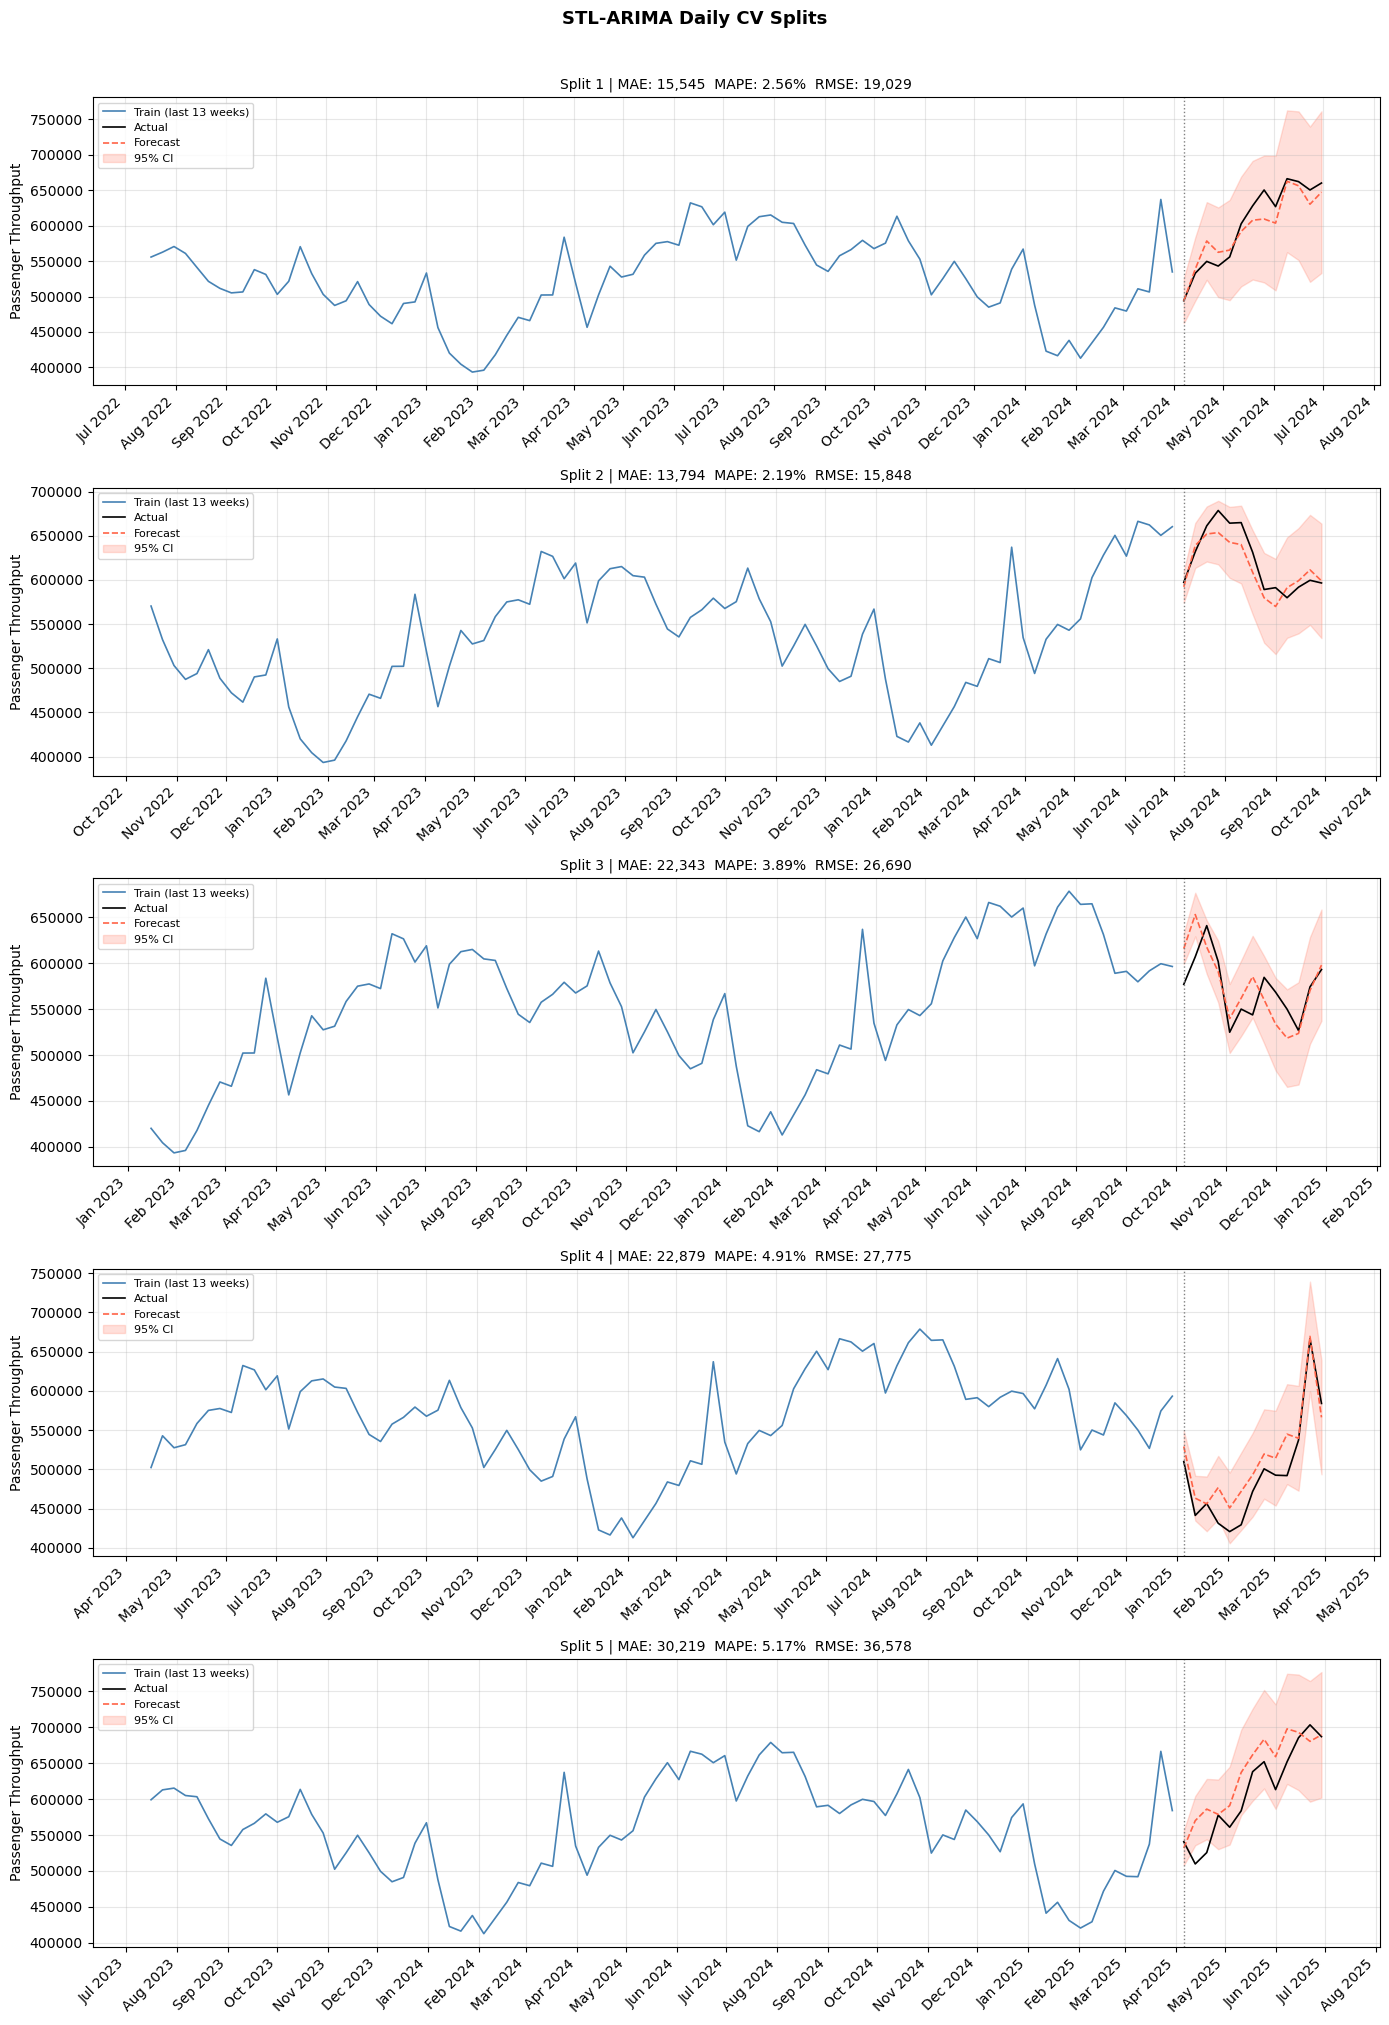

In [16]:


results_stl_w = []
fig, axes = plt.subplots(len(splits_w), 1, figsize=(14, 4 * len(splits_w)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_w):
    ax = axes[i]

    if len(test_idx) == 0:
        print(f"Split {i+1}: empty test set, skipping")
        ax.set_visible(False)
        continue

    train = data_ord_w_train.iloc[train_idx].copy()
    test  = data_ord_w_train.iloc[test_idx].copy()
    n_forecast = len(test_idx)

    model = STLArima(season_length=52, arima_order=(0,1,0), seasonal_order=(0,0,0,0))
    model.fit(train['total_passenger_throughput'])
    forecasts, lower_bound, upper_bound = model.forecast(n_forecast)

    actuals = test['total_passenger_throughput'].values
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_stl_w.append(metrics)

    # --- Plotting ---
    train_dates = train.index
    test_dates  = test.index

    # Plot last N days of training data for context
    context_window = min(90, len(train))
    ax.plot(train_dates[-context_window:],
            train['total_passenger_throughput'].values[-context_window:],
            color='steelblue', label='Train (last 13 weeks)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

    
plt.suptitle('STL-ARIMA Daily CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stl_arima_cv_splits.png', dpi=150, bbox_inches='tight')
plt.show()
